# Daily data

In [4]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv('../data/intermediate/monthly.csv')
df = df.drop(columns=["Unnamed: 0"])
df

,Region,Date,slavic_name,non_slavic_name,pmc,drafted,volunteers,prisoners,contract,total,...,region_type,region,position,governor,start,end,birth_year,insider,approved,nat_rep
0,Алтайский край,2022-02-01,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,Kraya (regions),Altay,Heads of the administration/governors,Viktor Tomenko,2018-05-30,2025-08-08,1971.0,0.0,1.0,0.0
1,Алтайский край,2022-03-01,33.0,2.0,0.0,0.0,0.0,0.0,35.0,35.0,...,Kraya (regions),Altay,Heads of the administration/governors,Viktor Tomenko,2018-05-30,2025-08-08,1971.0,0.0,1.0,0.0
2,Алтайский край,2022-04-01,30.0,2.0,0.0,0.0,2.0,0.0,30.0,32.0,...,Kraya (regions),Altay,Heads of the administration/governors,Viktor Tomenko,2018-05-30,2025-08-08,1971.0,0.0,1.0,0.0
3,Алтайский край,2022-05-01,57.0,5.0,0.0,0.0,2.0,0.0,60.0,62.0,...,Kraya (regions),Altay,Heads of the administration/governors,Viktor Tomenko,2018-05-30,2025-08-08,1971.0,0.0,1.0,0.0
4,Алтайский край,2022-06-01,31.0,3.0,0.0,0.0,4.0,0.0,30.0,34.0,...,Kraya (regions),Altay,Heads of the administration/governors,Viktor Tomenko,2018-05-30,2025-08-08,1971.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3550,Ярославская область,2025-03-01,4.0,1.0,0.0,0.0,0.0,0.0,1.0,5.0,...,Oblasti (provinces),Yaroslavl,"Head of the administration (from Dec 1995, gov...",Mikhail Yevrayev,2021-10-12,2025-08-08,1971.0,1.0,1.0,0.0
3551,Ярославская область,2025-04-01,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,Oblasti (provinces),Yaroslavl,"Head of the administration (from Dec 1995, gov...",Mikhail Yevrayev,2021-10-12,2025-08-08,1971.0,1.0,1.0,0.0
3552,Ярославская область,2025-05-01,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,Oblasti (provinces),Yaroslavl,"Head of the administration (from Dec 1995, gov...",Mikhail Yevrayev,2021-10-12,2025-08-08,1971.0,1.0,1.0,0.0
3553,Ярославская область,2025-06-01,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,Oblasti (provinces),Yaroslavl,"Head of the administration (from Dec 1995, gov...",Mikhail Yevrayev,2021-10-12,2025-08-08,1971.0,1.0,1.0,0.0


In [5]:
data = df.groupby('Date')[['pmc', 'drafted', 'volunteers', 'prisoners', 'contract', 'slavic_name', 'non_slavic_name', 'total']].sum().reset_index()
data['unknown'] = data['total'] - (data['pmc'] + data['contract'] + data['drafted'] + data['volunteers'] + data['prisoners'])

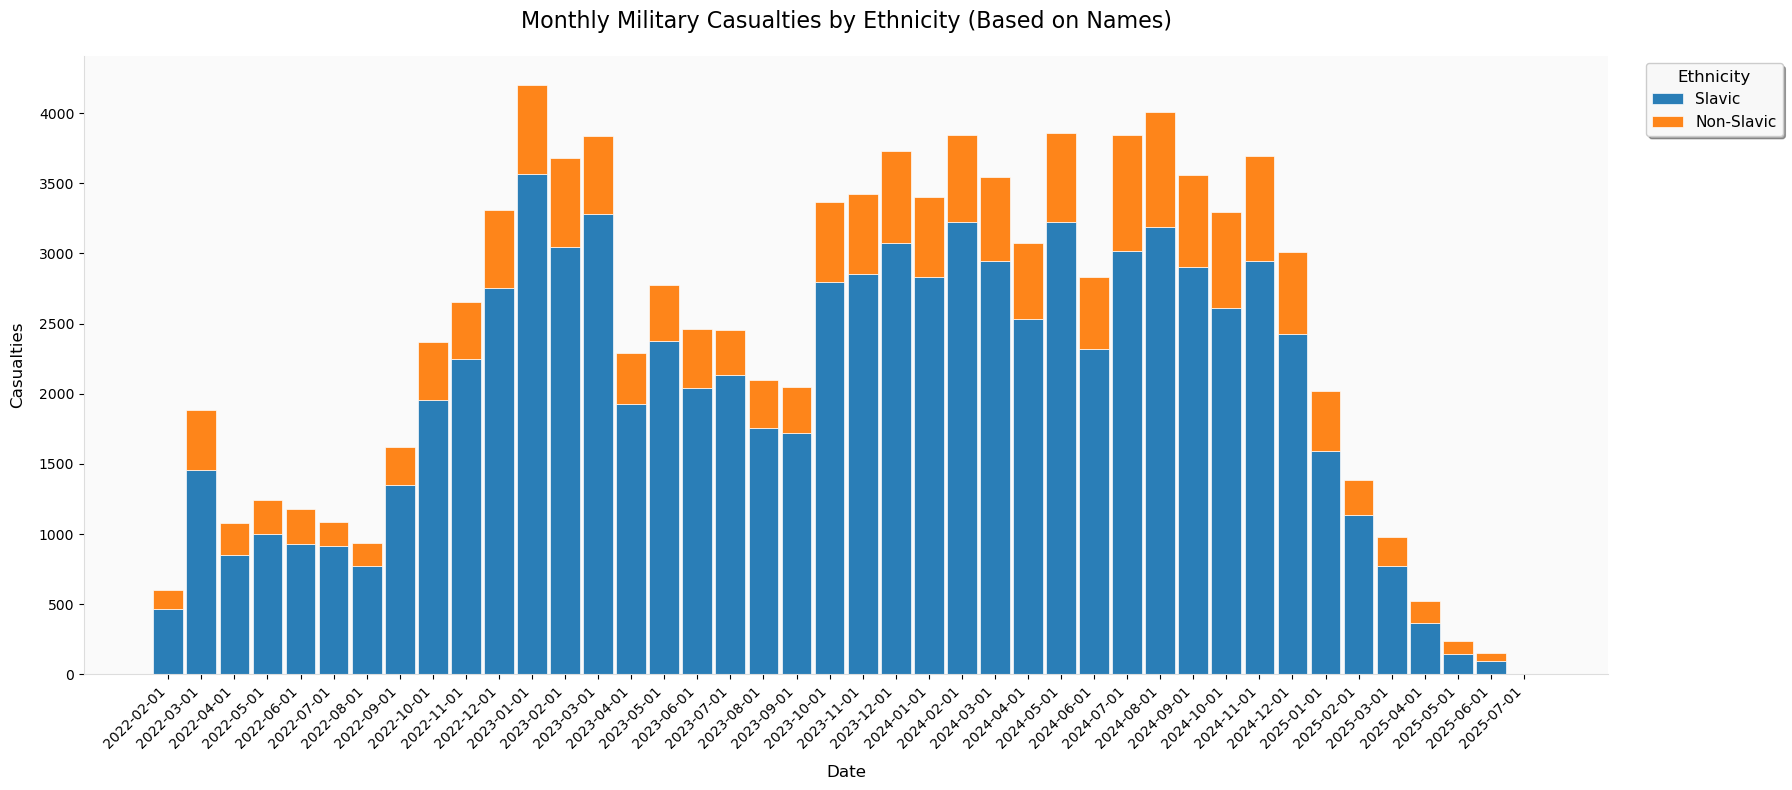

In [37]:

plt.figure(figsize=(18, 8))


legend_names = {
    'slavic_name': 'Slavic',
    'non_slavic_name': 'Non-Slavic'
}

# Define branches and colors
branches = ['slavic_name', 'non_slavic_name']
colors = sns.color_palette("tab10", 2)

# Plot stacked bars
bottom = None
for i, branch in enumerate(branches):
    plt.bar(
        data['Date'],
        data[branch],
        bottom=bottom,
        label=legend_names[branch],
        color=colors[i],
        width=0.9,
        edgecolor='white',
        linewidth=0.5,
        alpha=0.95
    )
    if bottom is None:
        bottom = data[branch].values
    else:
        bottom += data[branch].values



# Add styling elements
plt.title('Monthly Military Casualties by Ethnicity (Based on Names)', fontsize=16, pad=20)
plt.xlabel('Date', fontsize=12, labelpad=10)
plt.ylabel('Casualties', fontsize=12, labelpad=10)

plt.legend(
    title='Ethnicity',
    title_fontsize=12,
    fontsize=11,
    frameon=True,
    shadow=True,
    fancybox=True,
    facecolor='#f8f8f8',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_color('#dddddd')
plt.gca().spines['bottom'].set_color('#dddddd')

# Format date labels
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

# Add light background
plt.gca().set_facecolor('#fafafa')


plt.tight_layout()
plt.show()

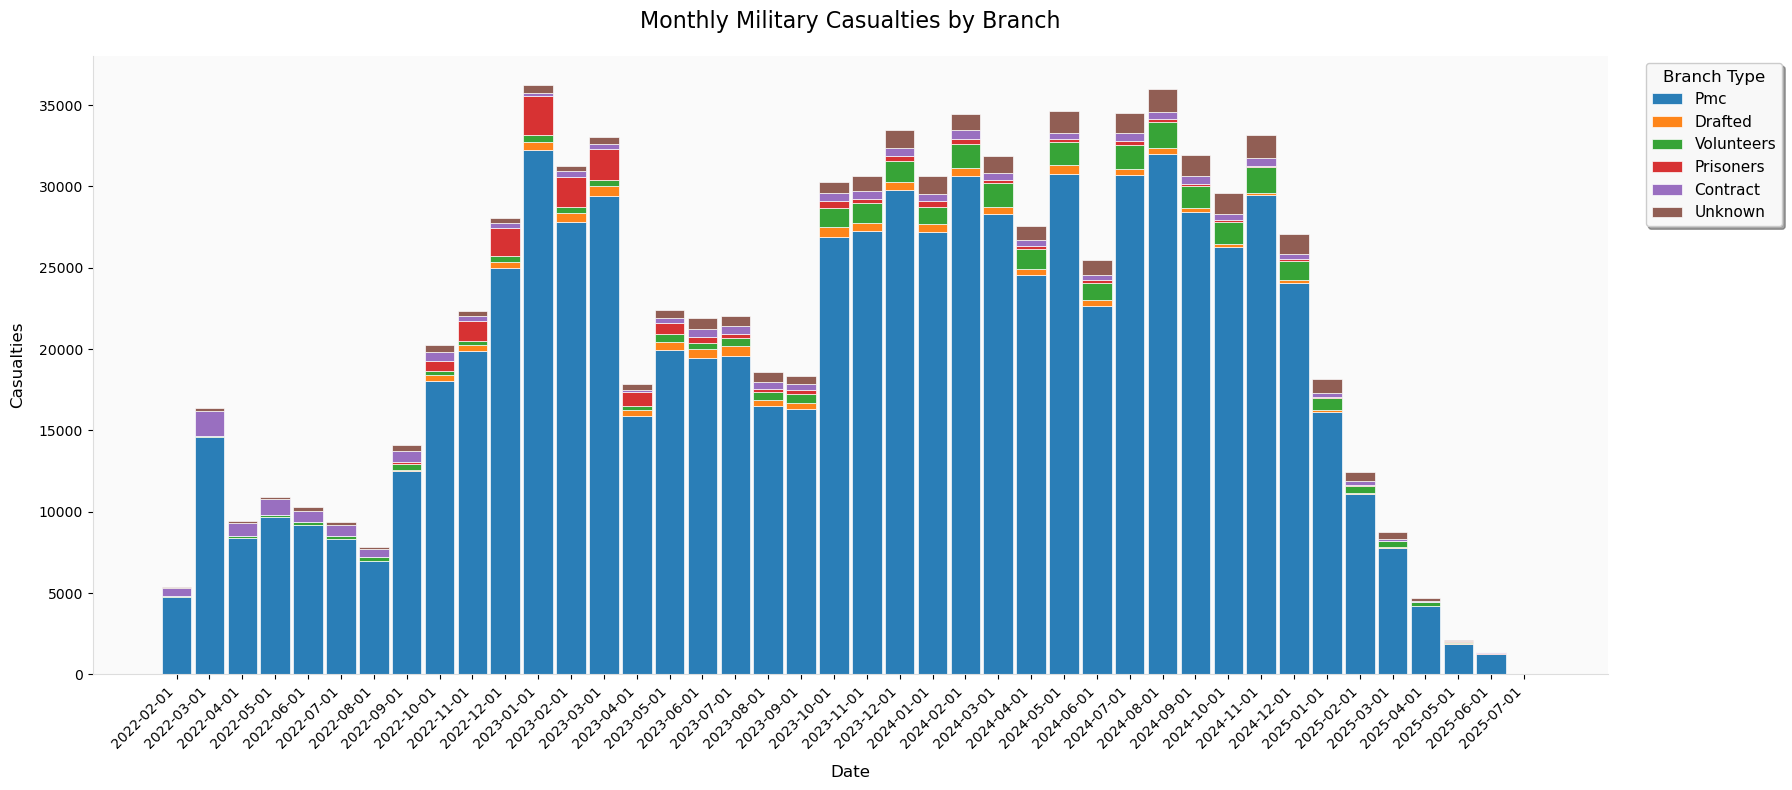

In [17]:

plt.figure(figsize=(18, 8))

# Define branches and colors
branches = ['pmc', 'drafted', 'volunteers', 'prisoners', 'contract', 'unknown']
colors = sns.color_palette("tab10", 6)

# Plot stacked bars
bottom = None
for i, branch in enumerate(branches):
    plt.bar(
        data['Date'],
        data[branch],
        bottom=bottom,
        label=branch.capitalize(),
        color=colors[i],
        width=0.9,
        edgecolor='white',
        linewidth=0.5,
        alpha=0.95
    )
    if bottom is None:
        bottom = data[branch].values
    else:
        bottom += data[branch].values



plt.title('Monthly Military Casualties by Branch', fontsize=16, pad=20)
plt.xlabel('Date', fontsize=12, labelpad=10)
plt.ylabel('Casualties', fontsize=12, labelpad=10)

plt.legend(
    title='Branch Type',
    title_fontsize=12,
    fontsize=11,
    frameon=True,
    shadow=True,
    fancybox=True,
    facecolor='#f8f8f8',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_color('#dddddd')
plt.gca().spines['bottom'].set_color('#dddddd')

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.gca().set_facecolor('#fafafa')
plt.tight_layout()
plt.show()

In [ ]:
daily = pd.read_csv('../data/daily.csv').drop(columns=["Unnamed: 0", 'Unnamed: 0.1'])
contract = ['автомобильные', 'артиллерия', 'ВДВ', 'военмед', 'военные пилоты',
       'войска связи', 'войсковая ПВО', 'инженерные войска', 'МВД','морпехи', 'моряки',
       'мотострелковые войска', 'наземные авиаслужбы', 'нацгвардия',
       'РХБЗ', 'спецназ', 'танковые войска', 'ФСБ', 
       'другие войска', 'ЖД', 'военная полиция', 'СК', 'ФСО']

daily["total"] = 1
daily["drafted"] = daily["pmc"] = daily["volunteers"] = daily["prisoners"] = daily['contract'] = 0
daily.loc[daily['branch'] == 'добровольцы', 'volunteers'] = 1
daily.loc[daily['branch'] == 'мобилизованные', 'drafted'] = 1
daily.loc[daily['branch'] == 'ЧВК', 'pmc'] = 1
daily.loc[daily['branch'] == 'заключенные', 'prisoners'] = 1
daily.loc[daily['branch'] ==  'нет данных', 'unknown'] = 1
daily.loc[daily['branch'].isin(contract), 'contract'] = 1


def create_branch_category(row):
    if row['volunteers'] == 1:
        return 'volunteers'
    elif row['drafted'] == 1:
        return 'drafted'
    elif row['pmc'] == 1:
        return 'pmc'
    elif row['prisoners'] == 1:
        return 'prisoners'
    elif row['unknown'] == 1:
        return 'unknown'
    elif row['contract'] == 1:
        return 'contract'
    else:
        return 'other'

daily['branch_category'] = daily.apply(create_branch_category, axis=1)



branch_category
unknown       33055
volunteers    32169
contract      20238
prisoners     17845
drafted       13090
pmc            2757
Name: count, dtype: int64

In [21]:
cross_tab = pd.crosstab(
    daily['branch_category'], 
    daily['slavic'],
    margins=True,  
    margins_name='Total'
)

print("Cross-tabulation Table:")
print(cross_tab)

Cross-tabulation Table:
slavic               0      1   Total
branch_category                      
contract          3945  16293   20238
drafted           2347  10743   13090
pmc                445   2312    2757
prisoners         2941  14904   17845
unknown           5290  27765   33055
volunteers        6802  25367   32169
Total            21770  97384  119154


In [ ]:
post_mob = df[(df['Date'] >= '2022-11-01')].copy()
post_mob['drafted_per_100k'] = (post_mob['drafted'] / post_mob['population']) * 100000
fatality_data = post_mob.groupby('Region').agg({
    'drafted': 'sum',
    'drafted_per_100k': 'sum'
}).reset_index()

pre_mob = df[(df['Date'] >= '2022-02-01') & (df['Date'] <= '2022-08-31')].copy()
pre_mob['fatalities_per_100k'] = (pre_mob['total'] / pre_mob['population']) * 100000
pre_fatality = pre_mob.groupby('Region').agg({
    'fatalities_per_100k': 'sum',
    'total': 'sum'
}).reset_index().rename(columns={
    'fatalities_per_100k': 'pre_total_per_100k',
    'total': 'pre_total_abs'
})

merged = pd.merge(marriage_data, fatality_data, on='Region')
merged = pd.merge(merged, pre_fatality, on='Region')
merged


,Region,Excessive Marriages,ex_nup_per100k,drafted,drafted_per_100k
0,Алтайский край,2007.6,430.387834,171.0,7.979840
1,Амурская область,1890.4,1007.471834,53.0,6.974602
2,Архангельская область без АО,684.2,311.861873,186.0,18.400356
3,Астраханская область,172.8,79.122691,83.0,8.698386
4,Белгородская область,1182.4,338.946125,139.0,9.111767
...,...,...,...,...,...
80,Чувашская Республика,185.6,71.876973,93.0,7.891053
81,Чукотский АО,69.4,531.027623,19.0,39.707419
82,Якутия,850.0,331.501624,236.0,23.654405
83,Ямало-Hенецкий АО,386.2,286.351942,25.0,4.884721


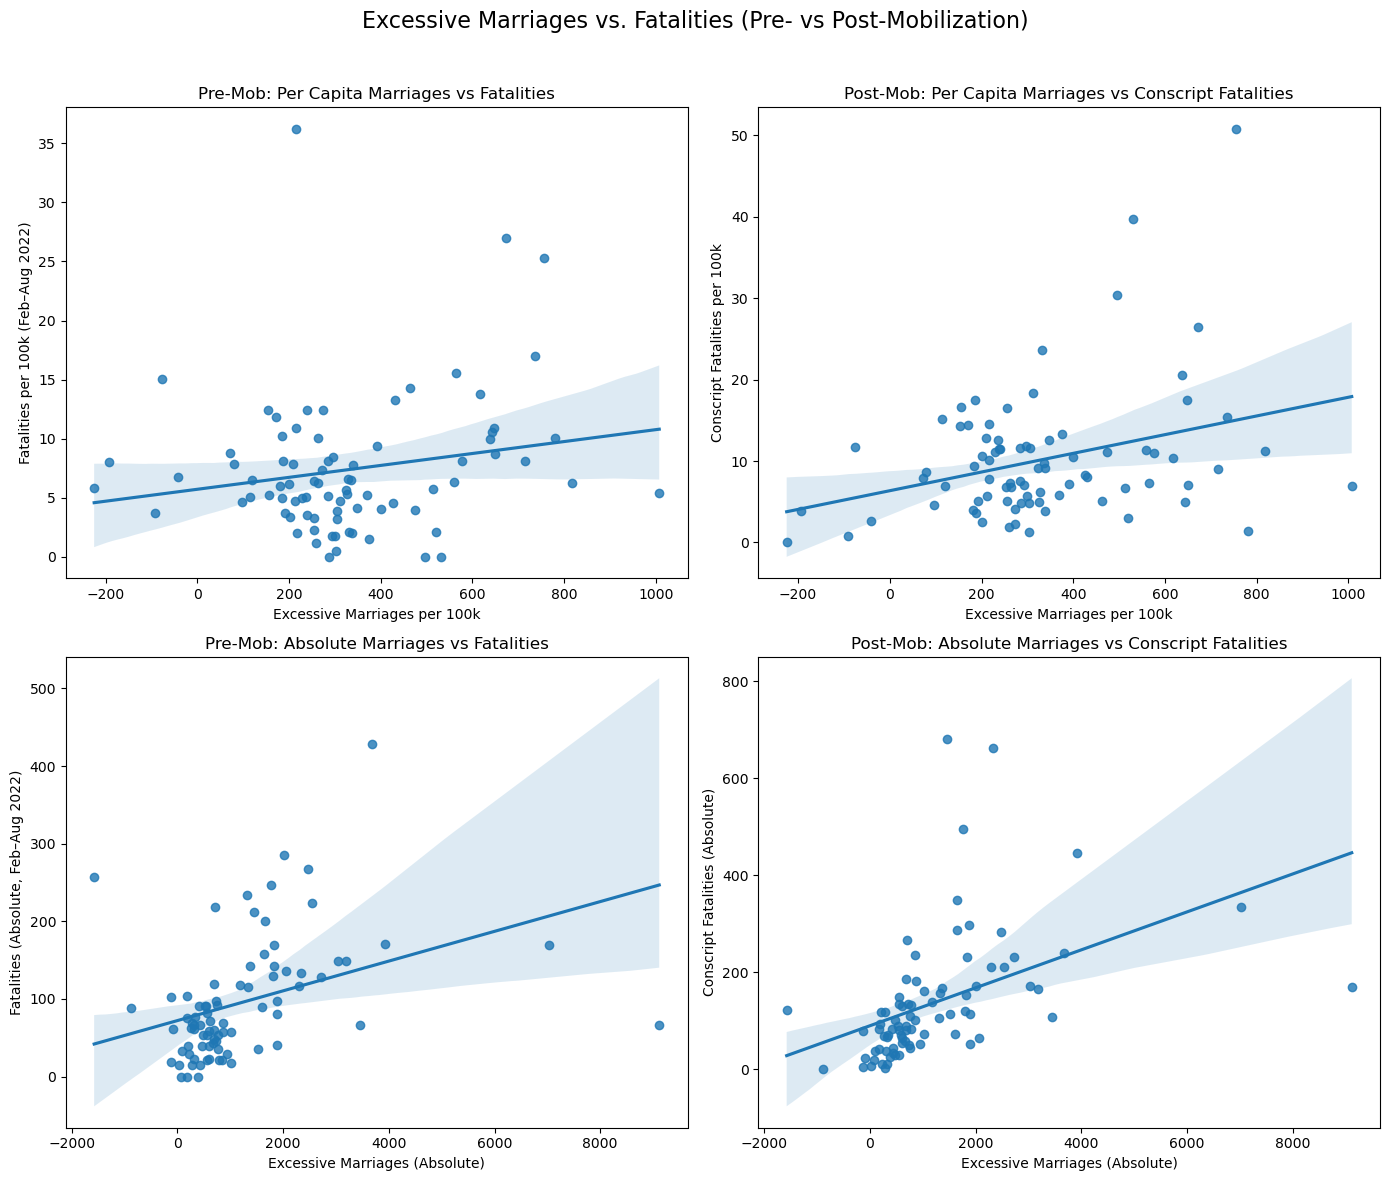

In [79]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Excessive Marriages vs. Fatalities (Pre- vs Post-Mobilization)', fontsize=16)

sns.regplot(data=merged, x='ex_nup_per100k', y='pre_total_per_100k', ax=axes[0, 0])
axes[0, 0].set_title('Pre-Mob: Per Capita Marriages vs Fatalities')
axes[0, 0].set_xlabel('Excessive Marriages per 100k')
axes[0, 0].set_ylabel('Fatalities per 100k (Feb–Aug 2022)')

sns.regplot(data=merged, x='ex_nup_per100k', y='drafted_per_100k', ax=axes[0, 1])
axes[0, 1].set_title('Post-Mob: Per Capita Marriages vs Conscript Fatalities')
axes[0, 1].set_xlabel('Excessive Marriages per 100k')
axes[0, 1].set_ylabel('Conscript Fatalities per 100k')

sns.regplot(data=merged, x='Excessive Marriages', y='pre_total_abs', ax=axes[1, 0])
axes[1, 0].set_title('Pre-Mob: Absolute Marriages vs Fatalities')
axes[1, 0].set_xlabel('Excessive Marriages (Absolute)')
axes[1, 0].set_ylabel('Fatalities (Absolute, Feb–Aug 2022)')

sns.regplot(data=merged, x='Excessive Marriages', y='drafted', ax=axes[1, 1])
axes[1, 1].set_title('Post-Mob: Absolute Marriages vs Conscript Fatalities')
axes[1, 1].set_xlabel('Excessive Marriages (Absolute)')
axes[1, 1].set_ylabel('Conscript Fatalities (Absolute)')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
